In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
# ensure project root is on sys.path so we can import the module
sys.path.append(str(Path.cwd()))
from randomForest_pipeline.load_data import load_data, add_dtypes

Load Data 

In [ ]:
# `add_dtypes` and `load_data` are provided by the randomForest_pipeline package
# we import them above (see top import cell).
# Use them like: df = load_data(processed=False)




In [12]:
def summarize(df: pd.DataFrame):
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:\n" + df.dtypes.to_string())
    nulls = df.isna().sum()
    if nulls.any():
        print("\nMissing values (non-zero):")
        print(nulls[nulls > 0].sort_values(ascending=False).to_string())
    else:
        print("\nMissing values: none")

    try:
        mem = df.memory_usage(deep=True).sum()
        print(f"\nApprox. memory usage: {mem/1024/1024:.2f} MB")
    except Exception:
        pass
    print("\nPreview:")
    display(df.head(5))
    print("\n" + "-" * 80)

In [ ]:
# # Load CSVs and show structure
# base = "/Users/kazimostafashahriar/Main Drive/thesis/Medical data analysis/Code"
# path_diabetic = f"{base}/diabetic_data.csv"
# path_ids = f"{base}/IDS_mapping.csv"

# # Read

# df = pd.read_csv(path_diabetic, na_values=["?"])
# ids_df = pd.read_csv(path_ids, na_values=["?"])



/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_42610/3125645934.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_diabetic, na_values=["?"])


In [9]:
df = load_data(processed=False)

/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_33284/3523505406.py:31: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(base+'/data/diabetic_data.csv', na_values=["?"])


In [13]:
summarize(df)

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
encounter_id                float64
patient_nbr                 float64
race                         object
gender                       object


Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
encounter_id                float64
patient_nbr                 float64
race                         object
gender                       object


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392.0,8222157.0,Caucasian,Female,[0-10),NaN,6,25,1,1.0,...,No,No,No,No,No,No,No,No,No,NO
1,149190.0,55629189.0,Caucasian,Female,[10-20),NaN,1,1,7,3.0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410.0,86047875.0,AfricanAmerican,Female,[20-30),NaN,1,1,7,2.0,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364.0,82442376.0,Caucasian,Male,[30-40),NaN,1,1,7,2.0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680.0,42519267.0,Caucasian,Male,[40-50),NaN,1,1,7,1.0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



--------------------------------------------------------------------------------


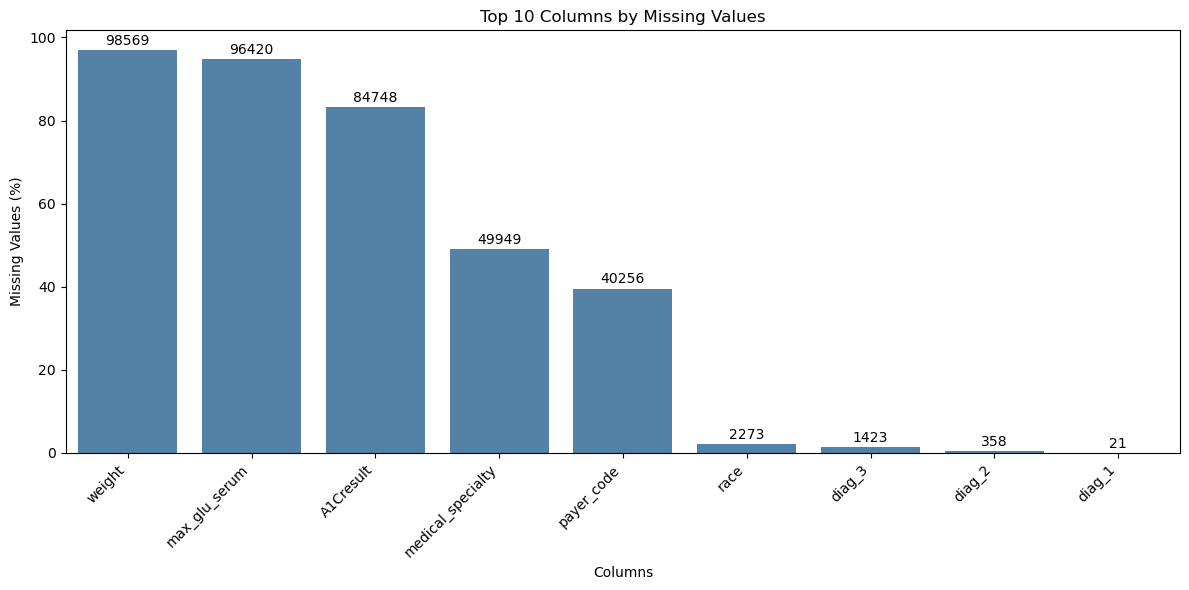

In [19]:

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False).head(10)

if missing_counts.empty:
    print("No missing values found.")
else:
    missing_pct = (missing_counts / len(df)) * 100

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=missing_counts.index, y=missing_pct.values, color="steelblue")

    ax.set_title("Top 10 Columns by Missing Values")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing Values (%)")
    plt.xticks(rotation=45, ha="right")

    # exact missing counts above each bar
    for i, (pct, cnt) in enumerate(zip(missing_pct.values, missing_counts.values)):
        ax.text(i, pct + 0.5, f"{cnt}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


In [21]:
# python
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

def zero_variance_cols(df):
    """Return list of columns with zero variance (single unique value)."""
    return [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

def near_zero_variance_cols(df, freq_ratio_thresh=20.0, unique_pct_thresh=10.0):
    """
    Detect near-zero-variance (NZV) columns (caret-style).
    - freq_ratio_thresh: ratio top / 2nd_top above which a column is NZV (default ~20).
    - unique_pct_thresh: percent unique values < this threshold considered NZV (default 10%).
    Works for categorical/object columns; numeric columns treated by unique pct.
    Returns a DataFrame with stats and a boolean 'is_nzv'.
    """
    n = len(df)
    rows = []
    for col in df.columns:
        ser = df[col].dropna().astype(str)
        nunique = ser.nunique()
        unique_pct = (nunique / n) * 100.0
        top_counts = ser.value_counts().values
        top = int(top_counts[0]) if top_counts.size > 0 else 0
        second = int(top_counts[1]) if top_counts.size > 1 else 0
        freq_ratio = (top / second) if second > 0 else np.inf
        is_nzv = (freq_ratio >= freq_ratio_thresh) and (unique_pct <= unique_pct_thresh)
        rows.append({
            "col": col,
            "n_unique": nunique,
            "unique_pct": unique_pct,
            "top_count": top,
            "second_count": second,
            "freq_ratio": freq_ratio,
            "is_nzv": is_nzv
        })
    return pd.DataFrame(rows).set_index("col").sort_values("is_nzv", ascending=False)

# sklearn helper for strictly zero-variance numeric columns
def sklearn_zero_variance(df):
    """Return zero-variance numeric columns using VarianceThreshold."""
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] == 0:
        return []
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(numeric.fillna(0))  # fillna to compute variance
    support = vt.get_support()
    zero_var_cols = numeric.columns[~support].tolist()
    return zero_var_cols

# Example usage:
# df = pd.read_csv("...") 
print("Zero-variance (single level):", zero_variance_cols(df))
print("SKLearn numeric zero-variance:", sklearn_zero_variance(df))
nzv_report = near_zero_variance_cols(df)
print(nzv_report[nzv_report["is_nzv"]])

Zero-variance (single level): ['examide', 'citoglipton']
SKLearn numeric zero-variance: []
                          n_unique  unique_pct  top_count  second_count  \
col                                                                       
repaglinide                      4    0.003931     100227          1384   
citoglipton                      1    0.000983     101766             0   
chlorpropamide                   4    0.003931     101680            79   
glimepiride                      4    0.003931      96575          4670   
acetohexamide                    2    0.001965     101765             1   
tolbutamide                      2    0.001965     101743            23   
acarbose                         4    0.003931     101458           295   
miglitol                         4    0.003931     101728            31   
troglitazone                     2    0.001965     101763             3   
examide                          1    0.000983     101766             0   
tolazamid

In [39]:
df["repaglinide"].value_counts(dropna=True)

repaglinide
No        100227
Steady      1384
Up           110
Down          45
Name: count, dtype: int64

In [38]:
df["gender"].isna().sum()

0